# Part 1 — Data preparation and leakage-free pipeline

**Project:** Predict Students' Dropout and Academic Success (UCI Machine Learning Repository).  
**Question:** Given information available through the end of semester 2, predict the eventual outcome: `Dropout`, `Enrolled`, or `Graduate`.  
**Primary metric:** macro F1, so the smaller `Enrolled` class counts equally. Also report per-class recall in later parts. No model is trained in Part 1.

The outcome is defined at the normal course duration, after the two semester measurements. This is an **end-of-year-1** prediction task, not an enrollment-time prediction. The semester columns must be removed if an enrollment-time task is attempted. Dataset approval and group registration are administrative requirements for the team to confirm with the instructor.

Source: [UCI dataset 697](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success), DOI: [10.24432/C5MC89](https://doi.org/10.24432/C5MC89), CC BY 4.0. The supplied `data.csv` is the local input. This notebook extends in later parts; keep the held-out test set untouched until final model evaluation.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

def locate_data():
    for path in (Path('../data.csv'), Path('data.csv')):
        if path.exists():
            return path
    raise FileNotFoundError('Run from assignment 1/ or repository root; data.csv is required')

data = pd.read_csv(locate_data())
assert data.shape == (4424, 37), f'Unexpected dataset shape: {data.shape}'
assert data['Target'].notna().all()
assert set(data['Target']) == {'Dropout', 'Enrolled', 'Graduate'}
print('Rows, columns:', data.shape)
print('Exact duplicate rows:', data.duplicated().sum())
print('Missing cells:', int(data.isna().sum().sum()))
display(data.head(3))

Rows, columns: (4424, 37)
Exact duplicate rows: 0
Missing cells: 0


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


## Split before exploration

The 20% test partition is stratified and held back. EDA, imputation statistics, outlier thresholds, categorical vocabularies, and scaling parameters are learned only from the training partition. The published file has no missing cells or exact duplicates; imputers still make the pipeline robust to future missing inputs. We retain unusual ages rather than dropping students, and cap numeric tails using training-set IQR fences.

In [2]:
X = data.drop(columns='Target')
y = data['Target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
train = X_train.assign(Target=y_train)
print('Training/test rows:', len(X_train), len(X_test))
display(pd.DataFrame({'train': y_train.value_counts(), 'test': y_test.value_counts()}))
print('Training missing cells:', int(X_train.isna().sum().sum()))
print('Training numeric age quantiles:')
display(X_train['Age at enrollment'].quantile([0, .25, .5, .75, 1]))

Training/test rows: 3539 885


,train,test
Target,,
Graduate,1767,442
Dropout,1137,284
Enrolled,635,159


Training missing cells: 0
Training numeric age quantiles:


0.00    17.0
0.25    19.0
0.50    20.0
0.75    25.0
1.00    70.0
Name: Age at enrollment, dtype: float64

## Exploratory data analysis — training partition only

The class distribution is imbalanced, especially for `Enrolled`. Semester-2 approved units and age may separate outcomes, but these plots are descriptive associations, not causal effects. Avoid interpreting a late academic measure as an enrollment-time predictor.

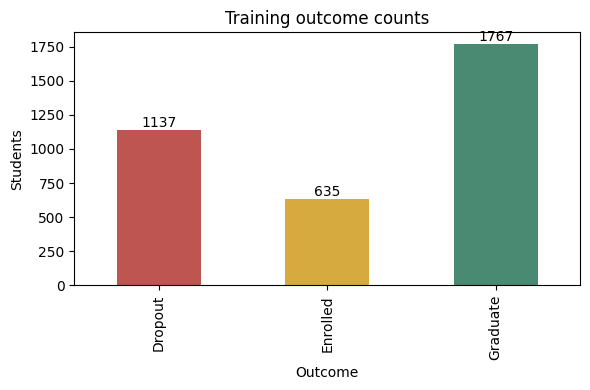

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = y_train.value_counts().reindex(['Dropout', 'Enrolled', 'Graduate'])
counts.plot.bar(ax=ax, color=['#be5550', '#d7aa3f', '#4b8a72'])
ax.set(title='Training outcome counts', xlabel='Outcome', ylabel='Students')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

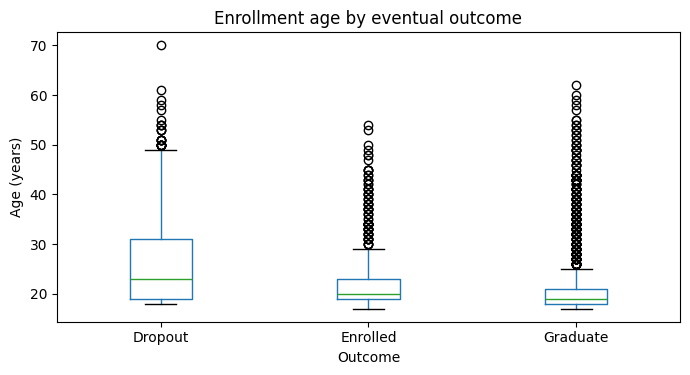

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
train.boxplot(column='Age at enrollment', by='Target', ax=ax, grid=False)
ax.set(title='Enrollment age by eventual outcome', xlabel='Outcome', ylabel='Age (years)')
fig.suptitle('')
plt.tight_layout()
plt.show()

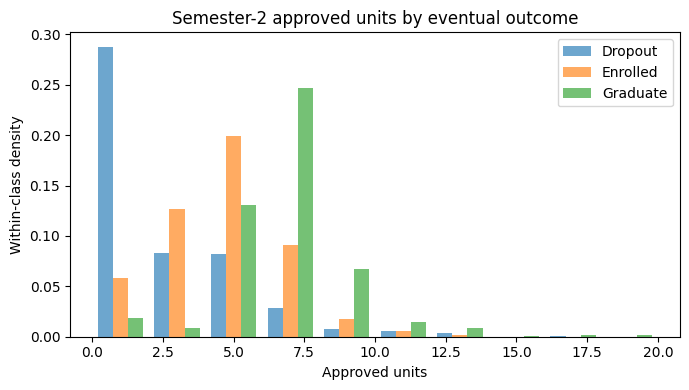

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
groups = [train.loc[train.Target == label, 'Curricular units 2nd sem (approved)']
          for label in ['Dropout', 'Enrolled', 'Graduate']]
ax.hist(groups, bins=np.arange(0, 22, 2), density=True, alpha=.65,
        label=['Dropout', 'Enrolled', 'Graduate'])
ax.set(title='Semester-2 approved units by eventual outcome',
       xlabel='Approved units', ylabel='Within-class density')
ax.legend()
plt.tight_layout()
plt.show()

## Feature design and preprocessing

The integer-coded fields below are categories rather than meaningful numeric distances. Binary indicators stay numeric. Two approval-rate features are built from enrolled/approved counts; a zero denominator becomes missing and is imputed within the pipeline. For continuous fields, median imputation precedes train-fitted IQR clipping and robust scaling. Categories use most-frequent imputation and one-hot encoding with unknown test categories ignored. The current class imbalance is documented; Part 2 model fitting should use stratified folds and, where supported, class weights fitted only on each training fold. We do not resample the full dataset before splitting.

In [6]:
class AcademicFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        out = X.copy()
        for semester in ('1st', '2nd'):
            prefix = f'Curricular units {semester} sem'
            denominator = out[f'{prefix} (enrolled)'].replace(0, np.nan)
            out[f'{semester} approval rate'] = out[f'{prefix} (approved)'] / denominator
        return out


class IQRClipper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        values = np.asarray(X, dtype=float)
        q1, q3 = np.percentile(values, [25, 75], axis=0)
        spread = q3 - q1
        self.lower_ = np.where(spread > 0, q1 - 1.5 * spread, -np.inf)
        self.upper_ = np.where(spread > 0, q3 + 1.5 * spread, np.inf)
        return self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


categorical = [
    'Marital status', 'Application mode', 'Course', 'Daytime/evening attendance',
    'Previous qualification', 'Nacionality', "Mother's qualification",
    "Father's qualification", "Mother's occupation", "Father's occupation",
]
binary = [
    'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date',
    'Gender', 'Scholarship holder', 'International',
]
constructed = ['1st approval rate', '2nd approval rate']
numeric = [c for c in X_train.columns if c not in categorical + binary] + constructed
assert len(categorical) + len(binary) + len(numeric) == X_train.shape[1] + 2

numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('clip', IQRClipper()),
    ('scale', RobustScaler()),
])
categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')), 
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
binary_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
])
preprocess = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric),
    ('categorical', categorical_pipeline, categorical),
    ('binary', binary_pipeline, binary),
], remainder='drop', verbose_feature_names_out=True)
part1_pipeline = Pipeline([
    ('features', AcademicFeatures()),
    ('preprocess', preprocess),
])
X_train_prepared = part1_pipeline.fit_transform(X_train, y_train)
X_test_prepared = part1_pipeline.transform(X_test)
feature_names = part1_pipeline.named_steps['preprocess'].get_feature_names_out()
assert X_train_prepared.shape[1] == X_test_prepared.shape[1] == len(feature_names)
assert np.isfinite(X_train_prepared).all() and np.isfinite(X_test_prepared).all()
print('Prepared train/test:', X_train_prepared.shape, X_test_prepared.shape)
print('First 15 output features:', feature_names[:15].tolist())

Prepared train/test: (3539, 239) (885, 239)
First 15 output features: ['numeric__Application order', 'numeric__Previous qualification (grade)', 'numeric__Admission grade', 'numeric__Age at enrollment', 'numeric__Curricular units 1st sem (credited)', 'numeric__Curricular units 1st sem (enrolled)', 'numeric__Curricular units 1st sem (evaluations)', 'numeric__Curricular units 1st sem (approved)', 'numeric__Curricular units 1st sem (grade)', 'numeric__Curricular units 1st sem (without evaluations)', 'numeric__Curricular units 2nd sem (credited)', 'numeric__Curricular units 2nd sem (enrolled)', 'numeric__Curricular units 2nd sem (evaluations)', 'numeric__Curricular units 2nd sem (approved)', 'numeric__Curricular units 2nd sem (grade)']


## Leakage checks and handoff

Only `X_train` is passed to `fit_transform`; `X_test` is passed to `transform`. The fitted imputation values, clipping fences, scaler values, and one-hot categories therefore come from training data. The outcome column never enters the transformer. For Part 2, place this same feature and preprocessing sequence **inside each estimator pipeline** before cross-validation so each fold learns its own preprocessing parameters. The `Enrolled` minority class is about 18% of the observations; macro F1 and per-class recall will expose weak performance on it. No test score is reported here because Part 1 requests data preparation, not model selection.